# Digital Camera Sales & TV Commercial Airings Analysis

Bi-lo Appliance Super-Store has outlets in several large metropolitan areas in New England. The general sales manager aired a commercial for a digital camera on selected local TV stations prior to a sale starting on Saturday and ending Sunday. She obtained the information for Saturday-Sunday digital camera sales at the various outlets and paired it with the number of times the advertisement was shown on the local TV stations.

| Location    | Airings ($x$) | Sales ($ thousands) ($y$) |
| :---------- | :------------ | :------------------------ |
| Providence  | 4             | 15                        |
| Springfield | 2             | 8                         |
| New Haven   | 5             | 21                        |
| Boston      | 6             | 24                        |
| Hartford    | 3             | 17                        |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.DataFrame({
    "Location": ["Providence", "Springfield", "New Haven", "Boston", "Hartford"],
    "Airings": [4, 2, 5, 6, 3],
    "Sales": [15, 8, 21, 24, 17]
})
df

,Location,Airings,Sales
0,Providence,4,15
1,Springfield,2,8
2,New Haven,5,21
3,Boston,6,24
4,Hartford,3,17


## a. What is the dependent variable?

- **Dependent variable ($y$):** **Digital camera sales (in thousands of dollars)**.
- **Independent variable ($x$):** **Number of commercial airings**.

*Explanation:* The general sales manager wants to find whether there is any relationship between commercial airings and digital camera sales. Since sales is the outcome expected to respond to or depend on the number of commercial airings, sales is the dependent variable.

## b. Draw a scatter diagram.

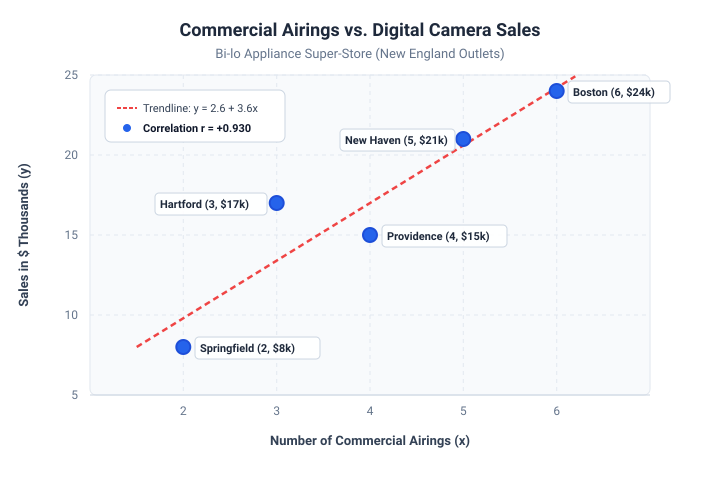

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))

# Scatter plot points
ax.scatter(df["Airings"], df["Sales"], color="#2563eb", s=100, zorder=3, edgecolors="#1d4ed8", linewidths=1.5)

# Add city labels
for _, row in df.iterrows():
    ax.annotate(
        f"{row['Location']} ({row['Airings']}, ${row['Sales']}k)",
        (row["Airings"], row["Sales"]),
        textcoords="offset points",
        xytext=(8, 5),
        fontsize=9,
        weight="bold"
    )

# Fit regression line: y = 2.6 + 3.6x
m, b = np.polyfit(df["Airings"], df["Sales"], 1)
x_line = np.linspace(1.5, 6.5, 100)
ax.plot(x_line, m * x_line + b, color="#ef4444", linestyle="--", linewidth=2, label=f"Fit: y = {b:.1f} + {m:.1f}x")

ax.set_title("Commercial Airings vs. Digital Camera Sales", fontsize=14, pad=12, fontweight="bold")
ax.set_xlabel("Number of Commercial Airings (x)", fontsize=11)
ax.set_ylabel("Sales ($ thousands) (y)", fontsize=11)
ax.set_xlim(1, 7)
ax.set_ylim(5, 27)
ax.grid(True, linestyle=":", alpha=0.6)
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

## c. Determine the correlation coefficient.

### Step-by-Step Calculation Table

Given $n = 5$ outlets:

- Mean of $x$: $\bar{x} = \frac{\sum x}{n} = \frac{20}{5} = 4$
- Mean of $y$: $\bar{y} = \frac{\sum y}{n} = \frac{85}{5} = 17$

| Location | $x$ (Airings) | $y$ (Sales) | $x - \bar{x}$ | $(x - \bar{x})^2$ | $y - \bar{y}$ | $(y - \bar{y})^2$ | $(x - \bar{x})(y - \bar{y})$ |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| Providence | 4 | 15 | 0 | 0 | -2 | 4 | 0 |
| Springfield | 2 | 8 | -2 | 4 | -9 | 81 | 18 |
| New Haven | 5 | 21 | 1 | 1 | 4 | 16 | 4 |
| Boston | 6 | 24 | 2 | 4 | 7 | 49 | 14 |
| Hartford | 3 | 17 | -1 | 1 | 0 | 0 | 0 |
| **Total ($\Sigma$)** | **20** | **85** | **0** | **10** | **0** | **150** | **36** |

### Formula and Substitution

$$SS_{xx} = \sum (x - \bar{x})^2 = 10$$
$$SS_{yy} = \sum (y - \bar{y})^2 = 150$$
$$SS_{xy} = \sum (x - \bar{x})(y - \bar{y}) = 36$$

$$r = \frac{SS_{xy}}{\sqrt{SS_{xx} \cdot SS_{yy}}} = \frac{36}{\sqrt{10 \times 150}} = \frac{36}{\sqrt{1500}} = \frac{36}{38.7298} \approx \mathbf{0.9295} \approx \mathbf{0.930}$$

In [4]:
r = df["Airings"].corr(df["Sales"])
r_sq = r ** 2
print(f"Pearson correlation coefficient r = {r:.4f}")
print(f"Coefficient of determination r^2 = {r_sq:.4f}")

Pearson correlation coefficient r = 0.9295
Coefficient of determination r^2 = 0.8640


## d. Interpret these statistical measures.

- **Direction and Strength:** $r \approx +0.93$ represents a **very strong positive linear relationship** between the number of commercial airings and digital camera sales.
- **Practical Meaning:** Increasing the number of TV commercial airings is strongly associated with higher digital camera sales.
- **Coefficient of Determination ($r^2$):** $r^2 \approx 0.864$ ($86.4\%$), meaning **$86.4\%$ of the total variation in digital camera sales** is explained by the number of times the advertisement was aired.